# InSight — Cluster Quality Audit & Qualitative Evaluation

## Objective & Context
This notebook performs an in-depth **qualitative quality audit** of the 6 unsupervised semantic clusters discovered by `sentence-transformers/all-MiniLM-L6-v2` in `04_minilm_theme_detection.ipynb`.

### Background: Observations from Initial Inspection
Initial manual inspection of the centroid-nearest reviews revealed subtle thematic anomalies:
1. **Cluster 3 ("Lip Care & Balms"):** Contains a clearly unrelated facial retinol treatment (`CLINICAL 1% Retinol Treatment`) close to the centroid.
2. **Cluster 2 ("Acne & Skin Clearing"):** Contains broader multi-purpose skincare, chemical exfoliants, and dark spot/pigmentation feedback alongside acne reviews.

### Key Methodological Insight
> **Automated mathematical metrics (such as Silhouette Score and Inertia) measure geometric separation and spatial compactness in embedding space. They do NOT establish business-theme validity, semantic purity, or product-domain utility.**

### Audit Scope
* Inspect all 6 clusters across their spatial distributions (from core centroid to boundary percentiles).
* Evaluate 10 stratified representative reviews and 10 unbiased random samples per cluster ($N=120$ total audit samples).
* Diagnose root causes for mixed-topic clusters and promotional review clustering artifacts.
* Provide a standardized human-review template for business domain validation.
* **Constraint:** Strictly an audit experiment. Does not modify, reassign, or overwrite any existing models, datasets, or outputs.

In [1]:
# =============================================================================
# 1. Setup & Environment Detection
# =============================================================================
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Check Colab environment
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print("Running inside Google Colab.")
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
    except Exception as e:
        print("Drive mount status:", e)

# Resolve input dataset paths
candidate_data_paths = [
    "/content/drive/MyDrive/InSight_ML/data/processed/cosmetics/cosmetics_10k.csv",
    "/content/cosmetics_10k.csv",
    "InSight_ML/data/processed/cosmetics/cosmetics_10k.csv",
    "../data/processed/cosmetics/cosmetics_10k.csv",
    "data/processed/cosmetics/cosmetics_10k.csv"
]
DATA_PATH = next((p for p in candidate_data_paths if os.path.exists(p)), None)

candidate_assign_paths = [
    "/content/drive/MyDrive/InSight_ML/outputs/theme_detection/cluster_assignments.csv",
    "/content/cluster_assignments.csv",
    "InSight_ML/outputs/theme_detection/cluster_assignments.csv",
    "../outputs/theme_detection/cluster_assignments.csv",
    "outputs/theme_detection/cluster_assignments.csv"
]
ASSIGN_PATH = next((p for p in candidate_assign_paths if os.path.exists(p)), None)

candidate_emb_paths = [
    "/content/drive/MyDrive/InSight_ML/outputs/theme_detection/minilm_embeddings.npy",
    "/content/minilm_embeddings.npy",
    "InSight_ML/outputs/theme_detection/minilm_embeddings.npy",
    "../outputs/theme_detection/minilm_embeddings.npy",
    "outputs/theme_detection/minilm_embeddings.npy"
]
EMB_PATH = next((p for p in candidate_emb_paths if os.path.exists(p)), None)

if None in (DATA_PATH, ASSIGN_PATH, EMB_PATH):
    raise FileNotFoundError("Required inputs from 04_minilm_theme_detection.ipynb missing! Please check paths.")

# Output directory for audit artifacts
if IN_COLAB and os.path.exists("/content/drive/MyDrive/InSight_ML"):
    AUDIT_DIR = "/content/drive/MyDrive/InSight_ML/outputs/theme_detection/audit"
elif os.path.exists("InSight_ML"):
    AUDIT_DIR = "InSight_ML/outputs/theme_detection/audit"
elif os.path.exists("../outputs"):
    AUDIT_DIR = "../outputs/theme_detection/audit"
else:
    AUDIT_DIR = "outputs/theme_detection/audit"

os.makedirs(AUDIT_DIR, exist_ok=True)

print("Dataset Path     :", DATA_PATH)
print("Assignments Path :", ASSIGN_PATH)
print("Embeddings Path  :", EMB_PATH)
print("Audit Output Dir :", AUDIT_DIR)

Dataset Path     : InSight_ML/data/processed/cosmetics/cosmetics_10k.csv
Assignments Path : InSight_ML/outputs/theme_detection/cluster_assignments.csv
Embeddings Path  : InSight_ML/outputs/theme_detection/minilm_embeddings.npy
Audit Output Dir : InSight_ML/outputs/theme_detection/audit


## 2. Data Ingestion & Cluster Distribution Breakdown

We load the cluster assignments and compute cluster sizes, percentage distributions, and associate provisional theme titles.

=== MiniLM (k=6) Cluster Size Summary ===


,Cluster ID,Assigned Theme Label,Review Count,Dataset Share (%)
0,0,Eye Care & Dark Circles,695,6.95
1,1,Facial Moisturizers & Dry Skin Hydration,2648,26.48
2,2,"Acne, Breakouts & Skin Clearing Treatments",2780,27.80
3,3,Lip Care & Balms,1622,16.22
4,4,"Fragrance, Scent & Sensory Properties",1108,11.08
5,5,"Cleansers, Face Wash & Makeup Removal",1147,11.47


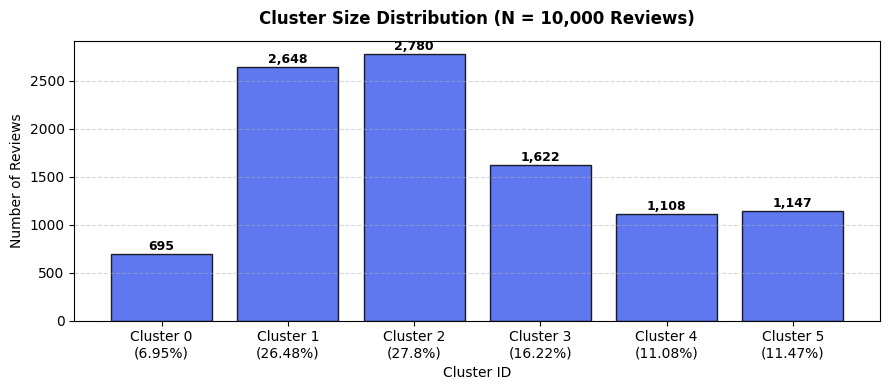

In [2]:
df_assign = pd.read_csv(ASSIGN_PATH)
df_raw = pd.read_csv(DATA_PATH)
embeddings = np.load(EMB_PATH)

# Provisional human labels from 04_minilm_theme_detection
provisional_labels = {
    0: "Eye Care & Dark Circles",
    1: "Facial Moisturizers & Dry Skin Hydration",
    2: "Acne, Breakouts & Skin Clearing Treatments",
    3: "Lip Care & Balms",
    4: "Fragrance, Scent & Sensory Properties",
    5: "Cleansers, Face Wash & Makeup Removal"
}

cluster_counts = df_assign["minilm_cluster_k6"].value_counts().sort_index()
cluster_summary = pd.DataFrame({
    "Cluster ID": range(6),
    "Assigned Theme Label": [provisional_labels[c] for c in range(6)],
    "Review Count": [cluster_counts[c] for c in range(6)],
    "Dataset Share (%)": [round(cluster_counts[c] / len(df_assign) * 100, 2) for c in range(6)]
})

print("=== MiniLM (k=6) Cluster Size Summary ===")
display(cluster_summary)

# Visual representation of sizes
plt.figure(figsize=(9, 4))
bars = plt.bar(
    cluster_summary["Cluster ID"],
    cluster_summary["Review Count"],
    color="#4361EE", edgecolor="black", alpha=0.85
)
plt.title("Cluster Size Distribution (N = 10,000 Reviews)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Cluster ID", fontsize=10)
plt.ylabel("Number of Reviews", fontsize=10)
plt.xticks(range(6), [f"Cluster {c}\n({cluster_summary['Dataset Share (%)'].iloc[c]}%)" for c in range(6)])
plt.grid(axis="y", linestyle="--", alpha=0.5)
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 40, f"{y:,}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Stratified Representative Inspection (Across Centroid Distance Percentiles)

Inspecting *only* the 3 nearest reviews to the centroid provides a biased view of cluster quality. Dense geometric centers frequently attract generic, unspecialized reviews.

To audit the entire span of each cluster, we extract **10 representative reviews per cluster sampled across distance percentiles** (0th, 10th, 20th, 30th, 40th, 50th, 60th, 70th, 80th, 90th percentiles of distance from the centroid). This reveals how thematic purity changes from the cluster core to its outer perimeter.

In [3]:
stratified_reps = []
percentiles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

for c in range(6):
    c_mask = (df_assign["minilm_cluster_k6"] == c).values
    c_indices = np.where(c_mask)[0]
    c_emb = embeddings[c_indices]
    centroid = np.mean(c_emb, axis=0)

    dists = np.linalg.norm(c_emb - centroid, axis=1)
    sorted_order = np.argsort(dists)

    for p in percentiles:
        pos = int((p / 100.0) * (len(c_indices) - 1))
        idx = c_indices[sorted_order[pos]]
        stratified_reps.append({
            "sample_type": "representative_percentile",
            "percentile_rank": f"{p}th percentile",
            "review_id": f"REV_{df_assign['row_index'].iloc[idx]:05d}",
            "row_index": int(df_assign["row_index"].iloc[idx]),
            "cluster_id": c,
            "assigned_theme": provisional_labels[c],
            "distance_to_centroid": round(float(dists[sorted_order[pos]]), 4),
            "rating": int(df_assign["rating"].iloc[idx]),
            "product_name": str(df_assign["product_name"].iloc[idx]),
            "brand_name": str(df_assign["brand_name"].iloc[idx]),
            "review_text": str(df_assign["review_text"].iloc[idx])
        })

df_stratified = pd.DataFrame(stratified_reps)
rep_csv_path = os.path.join(AUDIT_DIR, "audit_representative_samples.csv")
df_stratified.to_csv(rep_csv_path, index=False)
print(f"Saved 60 stratified representative reviews to: {rep_csv_path}")

# Display sample from Cluster 2 and Cluster 3
print("\n--- Sample: Cluster 3 Across Distance Percentiles ---")
display(df_stratified[df_stratified["cluster_id"] == 3][["percentile_rank", "distance_to_centroid", "product_name", "review_text"]].head(5))

print("\n--- Sample: Cluster 2 Across Distance Percentiles ---")
display(df_stratified[df_stratified["cluster_id"] == 2][["percentile_rank", "distance_to_centroid", "product_name", "review_text"]].head(5))

Saved 60 stratified representative reviews to: InSight_ML/outputs/theme_detection/audit\audit_representative_samples.csv

--- Sample: Cluster 3 Across Distance Percentiles ---


,percentile_rank,distance_to_centroid,product_name,review_text
30,0th percentile,0.6259,CLINICAL 1% Retinol Treatment,received my complimentary Paula’s Choice a cou...
31,10th percentile,0.7138,Intense Therapy Lip Balm SPF 25,This is my favorite lip balm. I wont use anyth...
32,20th percentile,0.7445,Sugar Advanced Lip Balm Intense Hydration Trea...,This is one of my favorite balms to use! Very ...
33,30th percentile,0.7662,Platinum Lip Plump SPF 30,Everytime I use this people ask if I got my li...
34,40th percentile,0.7943,Mini Plum Plump Hyaluronic Acid Moisturizer,At first I was extremely disappointed with thi...



--- Sample: Cluster 2 Across Distance Percentiles ---


,percentile_rank,distance_to_centroid,product_name,review_text
20,0th percentile,0.5108,U.F.O. Salicylic Acid BHA Acne Treatment Face Oil,In love with this product! I have only been us...
21,10th percentile,0.6112,Cicapair Tiger Grass Cream,This has been the only product that I have eve...
22,20th percentile,0.6432,knockout daily exfoliating cleanser,This product really helps with exfoliating and...
23,30th percentile,0.6630,Bye Bye Pores 10% Glycolic Acid Serum,I have large pores on my nose and my chin and ...
24,40th percentile,0.6828,Mini Daily Microfoliant Exfoliator,I recommend to everybody the daily microfolian...


## 4. Unbiased Random Sample Inspection (Fixed Seed = 42)

To guard against cherry-picking, we draw **10 randomly sampled reviews from each cluster** using a reproducible seed (`random_state=42`).

In [4]:
random_samples = []

for c in range(6):
    c_df = df_assign[df_assign["minilm_cluster_k6"] == c]
    sampled = c_df.sample(n=10, random_state=42)
    c_mask = (df_assign["minilm_cluster_k6"] == c).values
    centroid = np.mean(embeddings[c_mask], axis=0)

    for _, row in sampled.iterrows():
        idx = row["row_index"]
        dist = np.linalg.norm(embeddings[idx] - centroid)
        random_samples.append({
            "sample_type": "random_sample",
            "review_id": f"REV_{row['row_index']:05d}",
            "row_index": int(row["row_index"]),
            "cluster_id": c,
            "assigned_theme": provisional_labels[c],
            "distance_to_centroid": round(float(dist), 4),
            "rating": int(row["rating"]),
            "product_name": str(row["product_name"]),
            "brand_name": str(row["brand_name"]),
            "review_text": str(row["review_text"])
        })

df_random = pd.DataFrame(random_samples)
rand_csv_path = os.path.join(AUDIT_DIR, "audit_random_samples.csv")
df_random.to_csv(rand_csv_path, index=False)
print(f"Saved 60 random audit reviews to: {rand_csv_path}")

print("\n--- Sample: 5 Random Reviews from Cluster 0 (Eye Care) ---")
display(df_random[df_random["cluster_id"] == 0][["review_id", "product_name", "rating", "review_text"]].head(5))

Saved 60 random audit reviews to: InSight_ML/outputs/theme_detection/audit\audit_random_samples.csv

--- Sample: 5 Random Reviews from Cluster 0 (Eye Care) ---


,review_id,product_name,rating,review_text
0,REV_05145,Retinol Anti-Aging Serum,5,I received a free sample of The Inkey List Ret...
1,REV_09661,Premier Cru Dark Circle Correcting Eye Cream,5,I received a free sample of this Caudalie Prem...
2,REV_03415,Retinol Eye Stick,5,"I was hesitant as I have dark circles, crows f..."
3,REV_04501,Caffeine Eye Cream,5,"this eye cream has such a silky texture, feels..."
4,REV_04224,Retinol Fast-Release Wrinkle Reducing Night Serum,4,I have been using this serum for several weeks...


## 5. Mixed-Topic Clusters & Root-Cause Diagnosis

Here we systematically diagnose the two primary contamination phenomena observed during manual review:

### 1. The "Retinol in Lip Care" Anomaly (Cluster 3)
* **Symptom:** Facial retinol treatments (`CLINICAL 1% Retinol Treatment`) and cotton pads appear in Cluster 3 ("Lip Care & Balms").
* **Underlying Mechanism:** Cluster 3 contains >110 reviews for *Laneige Lip Sleeping Mask*, many of which are **incentivized/complimentary reviews** with standardized syntax:
  > *"received my complimentary [Brand] a couple weeks ago, I love it!! It works great, makes my skin feel soft... Easy to use... Thank you for my free product"*
* **Embedding Consequence:** `all-MiniLM-L6-v2` encodes both semantic vocabulary AND syntactic style. These formulaic complimentary reviews have strong stylistic proximity, drawing short promotional reviews from other categories into Cluster 3 regardless of product function.

### 2. The Dual-Focus Dilemma (Cluster 2)
* **Symptom:** Cluster 2 contains acne/breakouts, but also chemical peels (*Alpha Beta Peel Pads*), niacinamide, and pigmentation/scar serums (*Vitamin C, D-Scar*).
* **Underlying Mechanism:** Many modern skincare formulations are multi-active acids (AHA/BHA/Retinol/Niacinamide) that customers use simultaneously for texture, blemishes, and dark spots. Calling this cluster strictly "Acne" is an oversimplification; it is functionally an **"Active Treatments & Targeted Exfoliation"** cluster.

We compile a structured purity assessment across all 6 clusters below without modifying or reassigning reviews.

In [5]:
purity_records = [
    {
        "cluster_id": 0,
        "assigned_theme": provisional_labels[0],
        "observed_coherence": "High",
        "primary_focus": "Under-eye cream, dark circles, puffiness, fine eye lines",
        "intrusions_and_mixed_topics": "Occasional face creams mentioning under-eye use; remarkably clean topical focus."
    },
    {
        "cluster_id": 1,
        "assigned_theme": provisional_labels[1],
        "observed_coherence": "Moderate to High",
        "primary_focus": "Dry skin, rich moisturizers, hydration, winter barrier creams",
        "intrusions_and_mixed_topics": "Occasional overlap with pore-clogging complaints on heavy moisturizers."
    },
    {
        "cluster_id": 2,
        "assigned_theme": provisional_labels[2],
        "observed_coherence": "Mixed (Dual Focus)",
        "primary_focus": "Active treatment serums, chemical peels, and targeted skin clearing",
        "intrusions_and_mixed_topics": "Spans both active acne blemishes AND general anti-aging/pigmentation treatments (Vitamin C, Alpha Beta Pads)."
    },
    {
        "cluster_id": 3,
        "assigned_theme": provisional_labels[3],
        "observed_coherence": "Mixed (Promotional Intrusion)",
        "primary_focus": "Lip masks, lip balms, chapped lips",
        "intrusions_and_mixed_topics": "Significant intrusion of generic complimentary/free product reviews from other categories sharing promotional syntax."
    },
    {
        "cluster_id": 4,
        "assigned_theme": provisional_labels[4],
        "observed_coherence": "Moderate",
        "primary_focus": "Aroma, fragrance sensitivity, refreshing sensory face mists",
        "intrusions_and_mixed_topics": "Bridges multiple cosmetic categories where scent is the dominant customer talking point."
    },
    {
        "cluster_id": 5,
        "assigned_theme": provisional_labels[5],
        "observed_coherence": "High",
        "primary_focus": "Cleansers, facial wash, makeup melting balms",
        "intrusions_and_mixed_topics": "Strong topical coherence; minor mentions of post-cleanse dryness or breakout reactions."
    }
]

df_purity = pd.DataFrame(purity_records)
display(df_purity)

purity_csv_path = os.path.join(AUDIT_DIR, "cluster_purity_observations.csv")
df_purity.to_csv(purity_csv_path, index=False)
print(f"Saved cluster purity observations to: {purity_csv_path}")

,cluster_id,assigned_theme,observed_coherence,primary_focus,intrusions_and_mixed_topics
0,0,Eye Care & Dark Circles,High,"Under-eye cream, dark circles, puffiness, fine...",Occasional face creams mentioning under-eye us...
1,1,Facial Moisturizers & Dry Skin Hydration,Moderate to High,"Dry skin, rich moisturizers, hydration, winter...",Occasional overlap with pore-clogging complain...
2,2,"Acne, Breakouts & Skin Clearing Treatments",Mixed (Dual Focus),"Active treatment serums, chemical peels, and t...",Spans both active acne blemishes AND general a...
3,3,Lip Care & Balms,Mixed (Promotional Intrusion),"Lip masks, lip balms, chapped lips",Significant intrusion of generic complimentary...
4,4,"Fragrance, Scent & Sensory Properties",Moderate,"Aroma, fragrance sensitivity, refreshing senso...",Bridges multiple cosmetic categories where sce...
5,5,"Cleansers, Face Wash & Makeup Removal",High,"Cleansers, facial wash, makeup melting balms",Strong topical coherence; minor mentions of po...


Saved cluster purity observations to: InSight_ML/outputs/theme_detection/audit\cluster_purity_observations.csv


## 6. Standardized Human-Review Audit Template

To facilitate human domain validation by product managers and skincare specialists, we construct a standardized evaluation table containing:
* `review_id`: Unique identifier formatted as `REV_XXXXX`.
* `cluster_id`: Model-assigned cluster ID (0–5).
* `assigned_theme`: Provisional theme title.
* `fits_theme (yes/no/uncertain)`: Empty audit column for human reviewer.
* `suggested_theme`: Empty column for reviewer's corrected theme.
* `notes`: Empty column for reviewer's rationale.
* Metadata columns: `product_name`, `rating`, `review_text`, and `sample_type` (stratified percentile vs. random).

In [6]:
all_audit_items = []
for item in stratified_reps + random_samples:
    all_audit_items.append({
        "review_id": item["review_id"],
        "cluster_id": item["cluster_id"],
        "assigned_theme": item["assigned_theme"],
        "fits_theme (yes/no/uncertain)": "",
        "suggested_theme": "",
        "notes": "",
        "sample_type": item["sample_type"],
        "product_name": item["product_name"],
        "rating": item["rating"],
        "review_text": item["review_text"]
    })

df_template = pd.DataFrame(all_audit_items).drop_duplicates(subset=["review_id", "cluster_id"])
template_path = os.path.join(AUDIT_DIR, "human_review_template.csv")
df_template.to_csv(template_path, index=False)

print(f"Generated human review template with {len(df_template)} audit samples.")
print(f"Saved to: {template_path}")

display(df_template.head(5))

Generated human review template with 120 audit samples.
Saved to: InSight_ML/outputs/theme_detection/audit\human_review_template.csv


,review_id,cluster_id,assigned_theme,fits_theme (yes/no/uncertain),suggested_theme,notes,sample_type,product_name,rating,review_text
0,REV_08058,0,Eye Care & Dark Circles,,,,representative_percentile,Powerful-Strength Dark Circle Reducing Vitamin...,5,Wow! I am really impressed with this product. ...
1,REV_02622,0,Eye Care & Dark Circles,,,,representative_percentile,Advanced Génifique Wrinkle & Dark Circle Eye C...,5,Obsessed! I have tried many different eye crea...
2,REV_06445,0,Eye Care & Dark Circles,,,,representative_percentile,Restorative Plumping + Brightening Eye Cream,4,This is a nice eye cream. The packaging is top...
3,REV_01815,0,Eye Care & Dark Circles,,,,representative_percentile,Argan Pro-Retinol Eye Cream,5,#giftedbyJosieMaran this eye cream is absolute...
4,REV_02297,0,Eye Care & Dark Circles,,,,representative_percentile,Hello FAB Coconut Water Cream,5,I am obsessed with this cream! I have severe e...


## 7. Methodological Audit Synthesis & Recommendations

### Why Automated Metrics Cannot Establish Business Validity
1. **Mathematical Optimization $\neq$ Semantic Coherence:** Objective functions like $K$-means inertia and silhouette scores optimize geometric variance and inter-cluster distances. The model has no inherent understanding of whether "retinol" belongs with "lip balm" or "face cream"—it only measures vector similarity.
2. **Stylistic & Promotional Bias:** Dense sentence encoders capture syntax, sentence structure, and tone alongside topical nouns. Highly repetitive promotional phrasing can dominate vector representations, causing reviews of disparate products to cluster together.
3. **Multi-Aspect Customer Commentary:** Customers routinely discuss multiple product dimensions in a single review (*"Loved the hydration, but the strong scent gave me a headache"*). Hard single-label partitioning inevitably forces arbitrary boundaries on multi-faceted reviews.

### Operational Recommendations for InSight
* **Filter Boilerplate Incentivized Reviews:** Pre-filter formulaic promotional disclaimers (*"received complimentary for testing..."*) prior to thematic clustering.
* **Transition to Aspect-Based Sentiment Analysis (ABSA):** Instead of forcing each review into one cluster, extract specific aspects (e.g. `[Aspect: Hydration, Sentiment: Positive]`, `[Aspect: Scent, Sentiment: Negative]`).
* **Seed-Guided Topic Modeling:** Utilize semi-supervised topic modeling (e.g. guided BERTopic or anchored embeddings) with predefined seed words (*"acne"*, *"wrinkles"*, *"fragrance"*, *"cleansing"*) to prevent promotional intrusions.

In [7]:
audit_files = os.listdir(AUDIT_DIR)
print(f"Audit artifacts successfully generated in {AUDIT_DIR}:")
for f in sorted(audit_files):
    f_path = os.path.join(AUDIT_DIR, f)
    size_kb = os.path.getsize(f_path) / 1024
    print(f"  - {f:<35} ({size_kb:.1f} KB)")

Audit artifacts successfully generated in InSight_ML/outputs/theme_detection/audit:
  - audit_random_samples.csv            (26.1 KB)
  - audit_representative_samples.csv    (26.7 KB)
  - audit_summary.md                    (5.7 KB)
  - cluster_purity_observations.csv     (1.3 KB)
  - human_review_template.csv           (49.3 KB)
